# Week 13 - Sparse Kernel Machines (solution)

Solution author: Lukas Hedegaard (lh@eng.au.dk)

Learning contents:

* Constrained Optimization
    * Reformulate the problem as a maximization problem
    * Write out the Lagrangian function
    * Compute the gradients with respects to $x_1, x_2$, Lagrange multiplier $\lambda$ and the KKT multiplier $\mu$
    * Compute the optimum
* Support Vector Machine
    * Fit a linear SVM classifier, and plot the decision boundary, margin, and support vectors
    * Fit a non-linear SVM classifier using the RBF kernel, and plot the decision boundary, margin, and support vectors
    * Compare C=1 with C=1000 on the RBF-kernel SVM-classifier. What is the effect of a larger C? What could be the downside of a very large C?

In [1]:
# Dependencies
import numpy as np
import scipy
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set(); sns.set_palette('bright')

# 1) Support Vector Machines
As usual, we'll be working with a dataset of handwritten digits. 
Let visualise some examples.

In [2]:
# We're using a subset of two classes
digits = load_digits(n_class=2)

In [3]:
# Handy plotting functions
def plot_examples():
    show_num = 4
    _, axes = plt.subplots(1, show_num)
    images_and_labels = list(zip(digits.images, digits.target))
    for ax, (image, label) in zip(axes[:], images_and_labels[:show_num]):
        ax.set_axis_off()
        ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
        ax.set_title('Label: %i' % label)

def plot_scatter(data, target, alpha=0.5, legend=True):
    scatter = plt.scatter(data[:, 0], data[:, 1], c=target, edgecolor='none', alpha=alpha, cmap='rainbow')
    if legend:
        plt.legend(*scatter.legend_elements(), loc="upper right", title="Targets")
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')

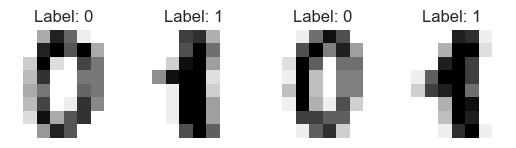

In [4]:
plot_examples()

In [5]:
# We can get a 2D version of the data using PCA
pca = PCA(n_components=2)
t = 2* digits.target -1 # {-1,1}
X = pca.fit_transform(digits.data)

# In order to get a non-linearly seperable case, 
# we'll modify the data a bit this time, 
# translating the '-1' class to the right
X = np.where(
    np.repeat(np.expand_dims(t == 1, axis=1), 2, axis=1), 
    X, 
    np.vstack([X[:,0]+15, X[:,1]]).T
)

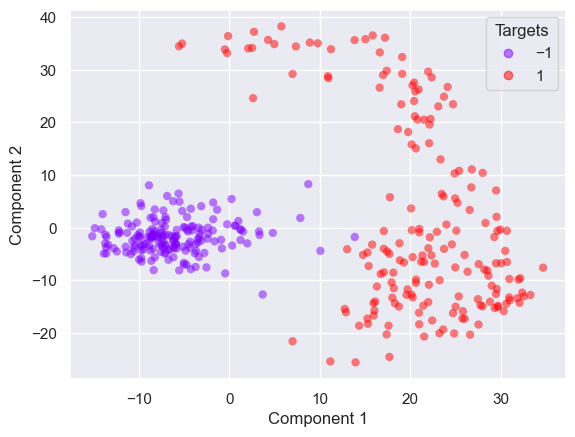

In [6]:
# Let's plot all the data in 2D
plot_scatter(X, t)

## 1.1) Fit a linear SVM classifier, and plot the decision boundary, margin, and support vectors
_Hint: use the SVM classifier from scikit-learn. The default C=1 will do just fine_

In [7]:
from sklearn.svm import SVC

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Courtesy of https://jakevdp.github.io/PythonDataScienceHandbook/"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=200, linewidth=1, edgecolors='black', facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

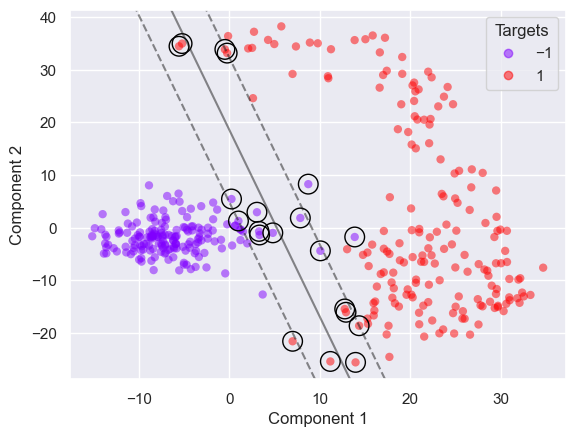

In [8]:
model_lin = SVC(kernel='linear', C=1)
model_lin.fit(X, t)

plot_scatter(X, t)
plot_svc_decision_function(model_lin)

## 1.2) Fit a non-linear SVM classifier using the RBF kernel, and plot the decision boundary, margin, and support vectors

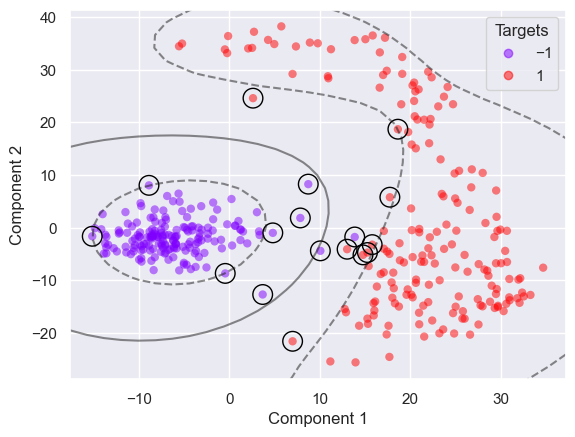

In [9]:
model_rbf = SVC(kernel='rbf', C=1)
model_rbf.fit(X, t)

plot_scatter(X, t)
plot_svc_decision_function(model_rbf)

## 1.3) Compare C=1 with C=1000 on the RBF-kernel SVM-classifier. What is the effect of a larger C? What could be the downside of a very large C?

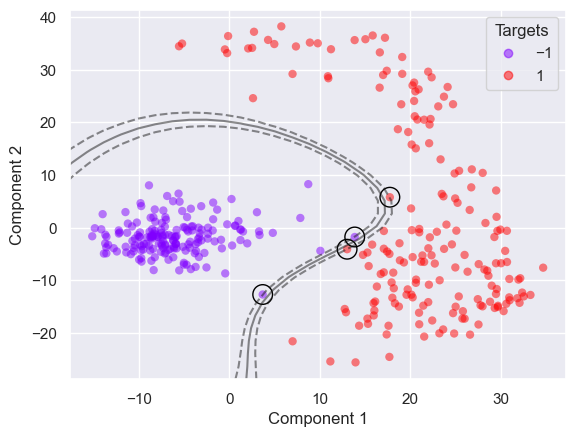

In [10]:
model_rbf = SVC(kernel='rbf', C=1000)
model_rbf.fit(X, t)

plot_scatter(X, t)
plot_svc_decision_function(model_rbf)

A larger C puts a larger penalty on the slack variables $\xi_n$. The penalty on the slack variables comes at the coster of a reduced margin. 
In the extreme case when $C \rightarrow \infty$, all slack is disallowed, and the classifier must be able to separate all points for a solution to be found. 

The possible downside of using a large C is that the classifier may _overfit_ to the training data. If we introduce new samples (not used for training), it may be that the classifier which had fit all training samples perfectly (very high C), would perform worse that the classifier which allowed some slack in the constraint (lower C), but didn't fit all samples perfectly